In [ ]:
!python3 -m pip install -r requirements.txt

# Расчётно-графическое задание по теме «Многомерные распределения»

**Вариант 18.**

Значения в верхней строке таблицы считаем значениями $X$ (столбцы), значения в левом столбце - значениями $Y$ (строки).

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
seed = 42

## Блок 1

### Задание 1

In [18]:
df = pd.read_csv('var18.csv', index_col=0)
df

,-100,-96,-63,-56,-41,14,19,24,28,74
XY,,,,,,,,,,
-73,0.001,0.0011,0.0003,0.0023,0.0004,0.0021,0.0005,0.001,0.0004,0.0009
-41,0.007,0.0077,0.0021,0.0161,0.0028,0.0147,0.0035,0.007,0.0028,0.0063
-38,0.013,0.0143,0.0039,0.0299,0.0052,0.0273,0.0065,0.013,0.0052,0.0117
-28,0.012,0.0132,0.0036,0.0276,0.0048,0.0252,0.0060,0.012,0.0048,0.0108
-19,0.002,0.0022,0.0006,0.0046,0.0008,0.0042,0.0010,0.002,0.0008,0.0018
10,0.030,0.0330,0.0090,0.0690,0.0120,0.0630,0.0150,0.030,0.0120,0.0270
30,0.006,0.0066,0.0018,0.0138,0.0024,0.0126,0.0030,0.006,0.0024,0.0054
41,0.004,0.0044,0.0012,0.0092,0.0016,0.0084,0.0020,0.004,0.0016,0.0036
51,0.004,0.0044,0.0012,0.0092,0.0016,0.0084,0.0020,0.004,0.0016,0.0036


In [19]:
x_vals = df.columns.astype(float).to_numpy()
y_vals = df.index.astype(float).to_numpy()
P = df.to_numpy(dtype=float)

### Задание 2

Одно из значений вероятности закона распределения не указано. Найдите его. Чем Вы воспользовались, чтобы найти это значение?

Воспользуемся условием нормировки: сумма вероятностей всех элементарных исходов дискретного распределения равна единице:
$$\sum_{i}\sum_{j} P(X=x_j,\ Y=y_i) = 1$$

In [20]:
nan_pos = np.argwhere(np.isnan(P))
i0, j0 = nan_pos[0]

missing = 1.0 - np.nansum(P) # очев почему
P[i0, j0] = missing

print(f"Пропущенное значение: X={x_vals[j0]}, Y={y_vals[i0]}")
print(f"P = {missing:.4f}")
print("Сумма всех вероятностей после заполнения пропуска:", round(P.sum(), 10))

Пропущенное значение: X=74.0, Y=82.0
P = 0.0189
Сумма всех вероятностей после заполнения пропуска: 1.0


### Задание 3

Найдите многомерную функцию распределения для заданного закона.

Функция распределения случайного вектора в $\mathbb{R}^2$ — это
$$F(x, y) = P(X \le x,\ Y \le y) = \sum_{x_j \le x}\ \sum_{y_i \le y} P(X=x_j,\ Y=y_i).$$

In [22]:
def joint_cdf(x, y):
    """
    F(x, y) = P(X <= x, Y <= y)
    """
    mask_x = x_vals <= x
    mask_y = y_vals <= y
    return P[mask_y, :][:, mask_x].sum()

F_table = np.zeros_like(P)
for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        F_table[i, j] = joint_cdf(x_vals[j], y_vals[i])

F_df = pd.DataFrame(np.round(F_table, 4), index=df.index, columns=df.columns)
print("Значения F(x, y):")
F_df

Значения F(x, y):


,-100,-96,-63,-56,-41,14,19,24,28,74
XY,,,,,,,,,,
-73,0.001,0.0021,0.0024,0.0047,0.0051,0.0072,0.0077,0.0087,0.0091,0.01
-41,0.008,0.0168,0.0192,0.0376,0.0408,0.0576,0.0616,0.0696,0.0728,0.08
-38,0.021,0.0441,0.0504,0.0987,0.1071,0.1512,0.1617,0.1827,0.1911,0.21
-28,0.033,0.0693,0.0792,0.1551,0.1683,0.2376,0.2541,0.2871,0.3003,0.33
-19,0.035,0.0735,0.0840,0.1645,0.1785,0.2520,0.2695,0.3045,0.3185,0.35
10,0.065,0.1365,0.1560,0.3055,0.3315,0.4680,0.5005,0.5655,0.5915,0.65
30,0.071,0.1491,0.1704,0.3337,0.3621,0.5112,0.5467,0.6177,0.6461,0.71
41,0.075,0.1575,0.1800,0.3525,0.3825,0.5400,0.5775,0.6525,0.6825,0.75
51,0.079,0.1659,0.1896,0.3713,0.4029,0.5688,0.6083,0.6873,0.7189,0.79


### Задание 4

Найдите законы и функции маргинальных распределений для каждой координаты заданного случайного вектора.

Постройте гистограммы для законов маргинальных распределений, где по оси абсцисс будут принимаемые случайными величинами значения, а по оси ординат вероятности их появления.

Постройте также графики функций распределения.

Маргинальный закон каждой координаты получается суммированием совместных вероятностей по другой координате:
$$P(X=x_j) = \sum_i P(X=x_j,\ Y=y_i), \qquad P(Y=y_i) = \sum_j P(X=x_j,\ Y=y_i).$$

Маргинальные функции распределения:
$$F_X(x) = \sum_{x_j \le x} P(X=x_j), \qquad F_Y(y) = \sum_{y_i \le y} P(Y=y_i).$$

In [24]:
p_X = P.sum(axis=0)
p_Y = P.sum(axis=1)

marg_X = pd.DataFrame({'x': x_vals.astype(int), 'P(X=x)': p_X})
marg_Y = pd.DataFrame({'y': y_vals.astype(int), 'P(Y=y)': p_Y})

print("Маргинальное распределение X:")
display(marg_X)
print("Маргинальное распределение Y:")
display(marg_Y)
print("Сумма P(X) =", round(p_X.sum(), 12), "  Сумма P(Y) =", round(p_Y.sum(), 10))

Маргинальное распределение X:


,x,P(X=x)
0,-100,0.10
1,-96,0.11
2,-63,0.03
3,-56,0.23
4,-41,0.04
5,14,0.21
6,19,0.05
7,24,0.10
8,28,0.04
9,74,0.09


Маргинальное распределение Y:


,y,P(Y=y)
0,-73,0.01
1,-41,0.07
2,-38,0.13
3,-28,0.12
4,-19,0.02
5,10,0.30
6,30,0.06
7,41,0.04
8,51,0.04
9,82,0.21


Сумма P(X) = 1.0   Сумма P(Y) = 1.0


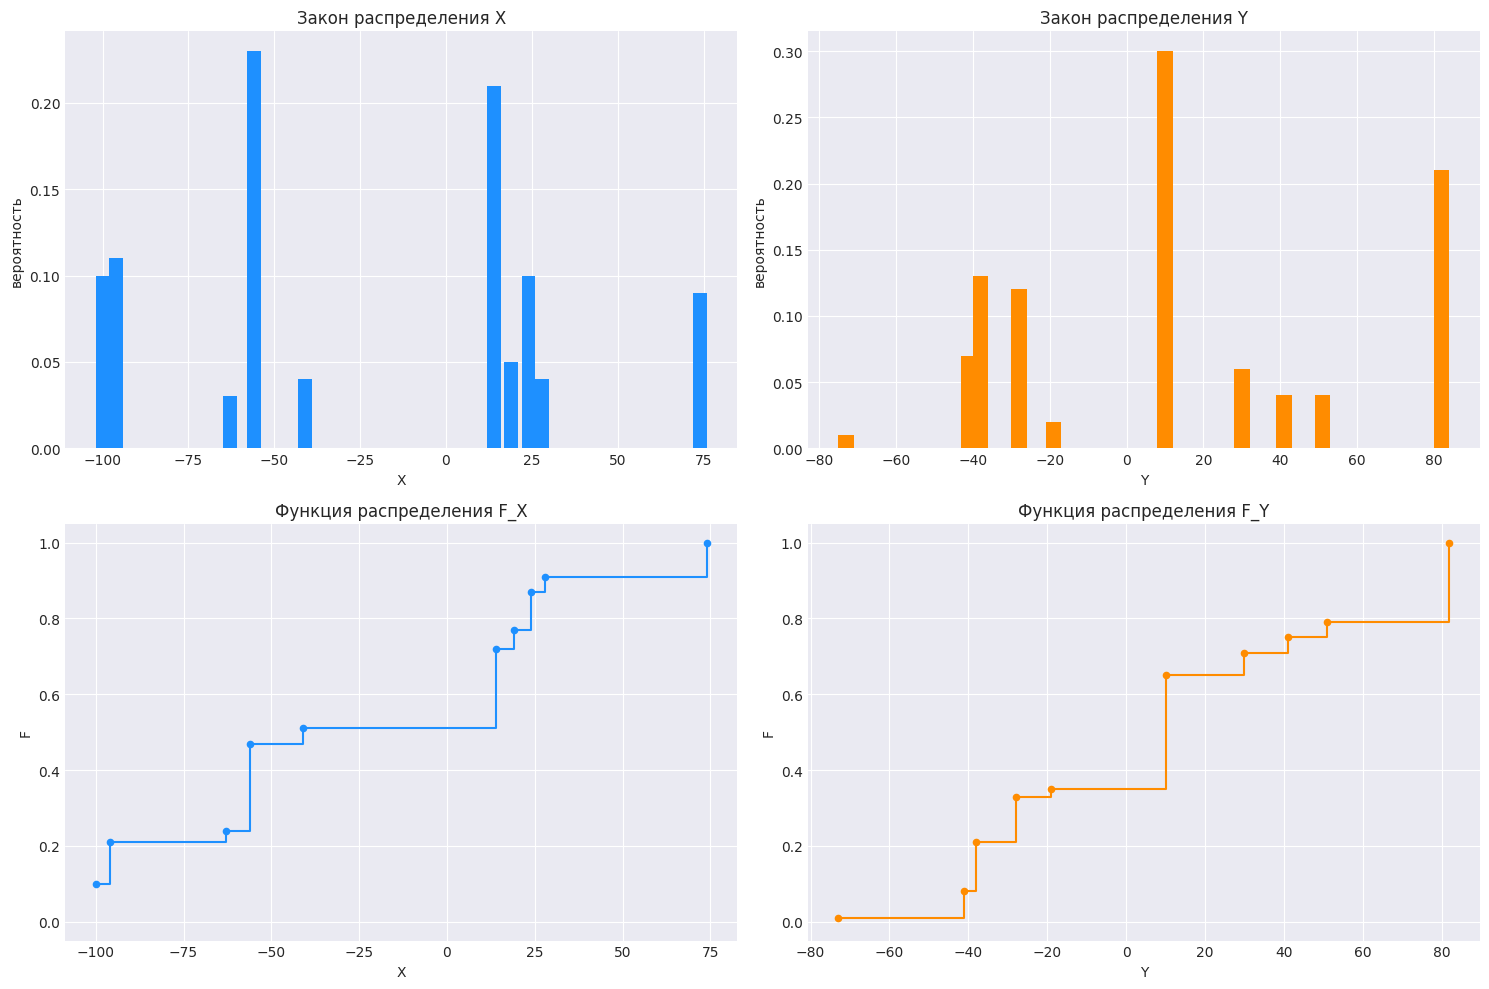

In [62]:
def plot_marginal(values, probs, color, label, ax_pmf, ax_cdf):
    order = np.argsort(values)
    v = values[order]
    pr = probs[order]
    cum = np.cumsum(pr)

    # гистограмма закона распределения
    ax_pmf.bar(v, pr, width=4, color=color)
    ax_pmf.set_title(f'Закон распределения {label}')
    ax_pmf.set_xlabel(label)
    ax_pmf.set_ylabel('вероятность')

    # ступенчатая функция распределения
    xs = v
    ys = cum
    ax_cdf.step(xs, ys, where='post', color=color)
    ax_cdf.scatter(v, cum, color=color, s=20)
    ax_cdf.set_title(f'Функция распределения F_{label}')
    ax_cdf.set_xlabel(label)
    ax_cdf.set_ylabel('F')
    ax_cdf.set_ylim(-0.05, 1.05)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_marginal(x_vals, p_X, 'dodgerblue', 'X', axes[0, 0], axes[1, 0])
plot_marginal(y_vals, p_Y, 'darkorange', 'Y', axes[0, 1], axes[1, 1])
plt.tight_layout()
plt.show()

### Задание 5. Числовые характеристики маргинальных распределений

Для маргинальных распределений найдите числовые характеристики:
- **Математическое ожидание:** $E[X]=\sum_j x_j\,P(X=x_j)$;
- **Дисперсию:** $D[X]=\sum_j (x_j-E[X])^2\,P(X=x_j)$;
- **Среднее квадратичное отклонение:** $\sigma_X=\sqrt{D[X]}$;
- **Медиану:** наименьшее значение $x$, для которого $F_X(x)\ge 0.5$;
- **Моду:** значение с наибольшей вероятностью.

In [52]:
def expectation(values, probs):
    return float(np.sum(values * probs))

def variance(values, probs):
    m = expectation(values, probs)
    return float(np.sum((values - m) ** 2 * probs))

def std_dev(values, probs):
    return math.sqrt(variance(values, probs))

def median_discrete(values, probs):
    order = np.argsort(values)
    v = values[order]
    cum = np.cumsum(probs[order])
    k = int(np.argmax(cum >= 0.5)) # первый индекс, где F >= 0.5
    return float(v[k])

def mode_discrete(values, probs):
    return float(values[int(np.argmax(probs))])

chars = pd.DataFrame({
    'X': [expectation(x_vals, p_X), variance(x_vals, p_X), std_dev(x_vals, p_X),
          median_discrete(x_vals, p_X), mode_discrete(x_vals, p_X)],
    'Y': [expectation(y_vals, p_Y), variance(y_vals, p_Y), std_dev(y_vals, p_Y),
          median_discrete(y_vals, p_Y), mode_discrete(y_vals, p_Y)],
}, index=['Мат. ожидание E', 'Дисперсия D', 'СКО', 'Медиана', 'Мода'])

chars.round(4)

,X,Y
Мат. ожидание E,-22.9000,13.4200
Дисперсия D,3037.9500,1947.2036
СКО,55.1176,44.1271
Медиана,-41.0000,10.0000
Мода,-56.0000,10.0000


### Задание 6
Проверьте независимость искомых случайных величин.

Случайные величины $X$ и $Y$ независимы тогда и только тогда, когда для **всех** пар значений выполняется
$$P(X=x_j,\ Y=y_i) = P(X=x_j)\cdot P(Y=y_i).$$

In [51]:
product = np.outer(p_Y, p_X)
diff = np.abs(P - product)

print("Max |P(x,y) - P(x)*P(y)|:", round(diff.max(), 10))

Max |P(x,y) - P(x)*P(y)|: 0.0


**Вывод.** Равенство $P(X=x_j,Y=y_i)=P(X=x_j)P(Y=y_i)$ выполняется для всех ячеек,$\implies$ $X$ и $Y$ **независимы**.

### Задание 7
Посчитайте коэффициент линейной корреляции данных величин. Равен ли он нулю? Есть ли тому причина? Что еще Вы можете сказать, глядя на него?

$$\operatorname{cov}(X,Y) = E[XY]-E[X]\,E[Y], \qquad r_{XY}=\frac{\operatorname{cov}(X,Y)}{\sigma_X\,\sigma_Y},$$
где 
$$E[XY]=\sum_i\sum_j x_j\,y_i\,P(X=x_j,Y=y_i)$$

In [54]:
EX = expectation(x_vals, p_X)
EY = expectation(y_vals, p_Y)

EXY = 0.0
for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        EXY += x_vals[j] * y_vals[i] * P[i, j]

cov = EXY - EX * EY
corr = cov / (std_dev(x_vals, p_X) * std_dev(y_vals, p_Y))

print(f"E[X]  = {EX:.4f}")
print(f"E[Y]  = {EY:.4f}")
print(f"E[XY] = {EXY:.4f}")
print(f"cov(X,Y) = {cov:4e}")
print(f"Коэффициент корреляции r = {corr:.4e}")

E[X]  = -22.9000
E[Y]  = 13.4200
E[XY] = -307.3180
cov(X,Y) = -5.684342e-13
Коэффициент корреляции r = -2.3371e-16


Коэффициент корреляции равен нулю

$X$ и $Y$ независимы, а независимые величины всегда некоррелированы — для них $E[XY]=E[X]E[Y]$, поэтому ковариация, а с ней и коэффициент корреляции, обращаются в ноль.

### Задание 8. Уравнение регрессии $Y$ на $X$
Постройте уравнение регрессии Y на X: $E(Y|X=x)$.

**Важное замечание:** в источниках под «уравнением регрессии» обычно понимают «эмпирическое уравнение регрессии», которое создается не для самих теоретических случайных величин, а для выборок из их распределений. С этими уравнениями Вы уже познакомитесь в следующем семестре, сейчас они нам не нужны.

$$E(Y\mid X=x) = \sum_i y_i\,P(Y=y_i\mid X=x), \qquad P(Y=y_i\mid X=x_j)=\frac{P(X=x_j,\ Y=y_i)}{P(X=x_j)}.$$

,x,E(Y|X=x)
0,-100,13.42
1,-96,13.42
2,-63,13.42
3,-56,13.42
4,-41,13.42
5,14,13.42
6,19,13.42
7,24,13.42
8,28,13.42
9,74,13.42


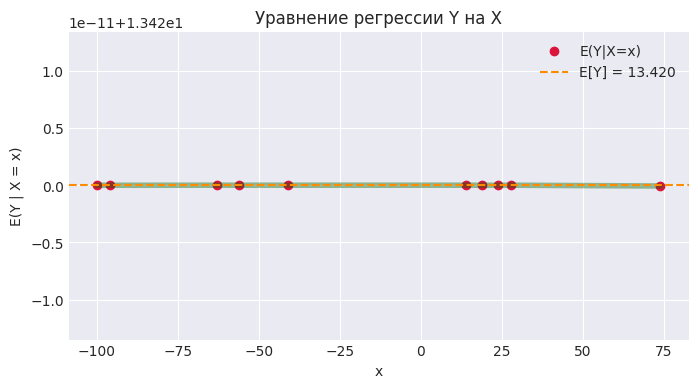

In [61]:
cond_means = []
for j in range(len(x_vals)):
    col = P[:, j]
    cond = col / col.sum()              # P(Y=y_i | X=x_j)
    cond_means.append(expectation(y_vals, cond))
cond_means = np.array(cond_means)

reg_df = pd.DataFrame({'x': x_vals.astype(int), 'E(Y|X=x)': cond_means})
display(reg_df.round(4))

order = np.argsort(x_vals)
plt.scatter(x_vals, cond_means, color='crimson', label='E(Y|X=x)')
plt.plot(x_vals[order], cond_means[order], color='darkgreen', alpha=0.4, linewidth = 4)
plt.axhline(EY, color='darkorange', ls='--', label=f'E[Y] = {EY:.3f}')
plt.title('Уравнение регрессии Y на X')
plt.xlabel('x')
plt.ylabel('E(Y | X = x)')
plt.legend()
plt.show()

Так как $X$ и $Y$ независимы, условное распределение $Y$ при $X=x$ совпадает с безусловным: $P(Y=y\mid X=x)=P(Y=y)$. Поэтому
$$E(Y\mid X=x) = E[Y] = \text{const}$$
для всех $x$.

## Блок 2. Моделирование

### Задание 1
Выберите одно из маргинальных распределений (X или Y) и смоделируйте данные из этого распределения. Возьмите не менее 10000 значений.

Из генераторов случайных чисел Вам разрешается использовать только стандартный датчик (тот, который генерирует равномерно числа из промежутка <0; 1>).

Разобьём отрезок $[0,1)$ на подотрезки, длины которых равны вероятностям $P(X=x_j)$. Сгенерировав $u\sim U(0,1)$, выбирем то значение, в подотрезок которого попало $u$ — то есть наименьшее $x_k \subset F_X(x_k) > u$:
$$X = x_k \iff F_X(x_{k-1}) \le u < F_X(x_k).$$

In [ ]:
random.seed(seed))

order = np.argsort(x_vals)
xs_sorted = x_vals[order]
ps_sorted = p_X[order]
cum_X = np.cumsum(ps_sorted) # F_X в точках xs_sorted

def sample_X():
    u = random.random()
    for k in range(len(xs_sorted)):
        if u < cum_X[k]:
            return xs_sorted[k]
    return xs_sorted[-1]

N = 20000
sample = np.array([sample_X() for _ in range(N)])

print(f"Сгенерировано {N} значений X")
print("Первые 10:", sample[:20].astype(int))

Сгенерировано 20000 значений X
Первые 10: [  14 -100  -56  -63   19   14   28 -100  -56 -100  -63  -41 -100  -96
   14   14  -63   14   24 -100]


### Задание 2
Составьте таблицу, где Вы для каждого значения случайной величины посчитаете относительную частоту ее появления в сгенерированных данных. Постройте по этой таблице гистограмму, аналогичную заданию 1.4.

Сравните данную гистограмму с гистограммой закона распределения из упомянутого задания. Похожи ли они? Обоснуйте с точки зрения теории вероятностей, почему они (не)похожи.

,x,P(X=x),отн. частота в сгенерированных,разница
0,-100,0.10,0.09860,0.00140
1,-96,0.11,0.11390,0.00390
2,-63,0.03,0.02700,0.00300
3,-56,0.23,0.22695,0.00305
4,-41,0.04,0.04035,0.00035
5,14,0.21,0.21005,0.00005
6,19,0.05,0.05190,0.00190
7,24,0.10,0.10355,0.00355
8,28,0.04,0.03635,0.00365
9,74,0.09,0.09135,0.00135


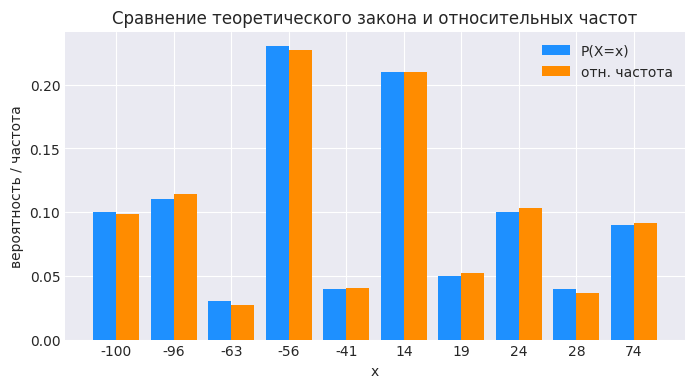

<Figure size 1600x900 with 0 Axes>

In [69]:
freq = np.array([np.sum(sample == v) / N for v in xs_sorted])

compare = pd.DataFrame({
    'x': xs_sorted.astype(int),
    'P(X=x)': ps_sorted,
    'отн. частота в сгенерированных': freq,
    'разница': np.abs(ps_sorted - freq),
})
display(compare.round(5))

idx = np.arange(len(xs_sorted))
w = 0.4
plt.bar(idx - w / 2, ps_sorted, width=w, label='P(X=x)',
        color='dodgerblue')
plt.bar(idx + w / 2, freq, width=w, label='отн. частота',
        color='darkorange')
plt.xticks(idx, [int(v) for v in xs_sorted])
plt.xlabel('x')
plt.ylabel('вероятность / частота')
plt.title('Сравнение теоретического закона и относительных частот')
plt.legend()
plt.figure(figsize=(16,9))
plt.show()

Гистограмма относительных частот очень близка к гистограмме теоретического закона распределения (задание 1.4).

Это объясняется законом больших чисел: относительная частота события при увеличении числа независимых испытаний сходится по вероятности к вероятности этого события. Для каждого фиксированного значения $x_j$ индикатор события $\{X=x_j\}$ — это схема Бернулли с вероятностью «успеха» $p=P(X=x_j)$; при $N=20000$ относительная частота $\frac{m}{N}$ близка к $p$. Поэтому гистограммы похожи. Небольшие расхождения - следствие конечности выборки; при увеличении $N$ они уменьшатся.

### Задание 3. Сходимость средних арифметических

Возьмите любую конечную возрастающую натуральную последовательность чисел $\{n_{i}\}_{i=1}^{N}$ достаточно большую, чтобы построить наглядный график. При необходимости сгенерируйте больше данных.

Для каждого значения $n_{i}$ возьмите $n_{i}$ сгенерированных значений и посчитайте для них среднее арифметическое: $a_{i}=\frac{S_{n_{i}}}{n_{i}}$.

Постройте график зависимости $a_{i}$ от $n_{i}$. Какое поведение Вы наблюдаете? Объясните с точки зрения теории вероятностей, почему оно именно такое.

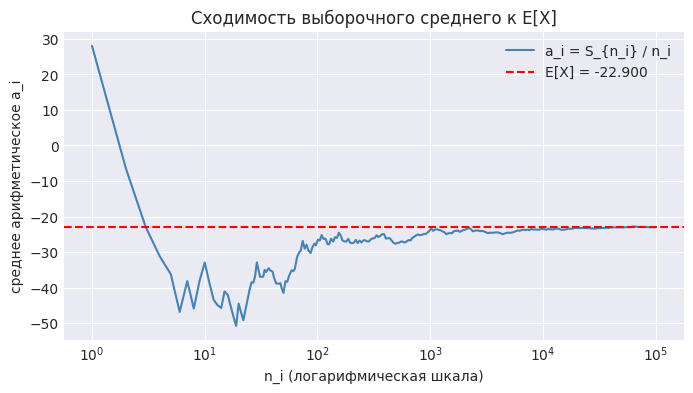

In [ ]:
big_N = 100000
big = np.array([sample_X() for _ in range(big_N)])
S = np.cumsum(big)

n_seq = np.unique(np.logspace(0, np.log10(big_N), 300).astype(int))
a = np.array([S[n - 1] / n for n in n_seq])

plt.plot(n_seq, a, color='steelblue', label='a_i = S_{n_i} / n_i')
plt.axhline(EX, color='red', ls='--', label=f'E[X] = {EX:.3f}')
plt.xscale('log')
plt.xlabel('n_i (логарифмическая шкала)')
plt.ylabel('среднее арифметическое a_i')
plt.title('Сходимость выборочного среднего к E[X]')
plt.legend()
plt.figure(figsize=(16,9))
plt.show()

При малых $n_i$ среднее арифметическое $a_i$ сильно колеблется, но с ростом $n_i$ колебания затухают, и $a_i$ сходится к матожиданию $E[X]$

## Бонусный вопрос
Как Вы могли предположить, параметры исходного закона многомерного распределения были сгенерированы программно. И если на значения случайных величин ограничения могут быть наложены произвольно, то на вероятности ограничения возникают естественно.

Предложите алгоритм, который для любых N, M и P способен равновероятно сгенерировать любой вариант из возможных корректных распределений вероятностей для дискретного двумерного распределения с таблицей размера $N*M$ так, чтобы каждое значение вероятности в своем десятичном представлении имело не более P знаков после запятой.

Вместе с этим предложите также алгоритм, который схожим образом генерирует распределение вероятностей, но с условием, что координаты случайного вектора должны быть независимы.

Если вероятность имеет не более $P$ знаков после запятой, то она кратна $10^{-P}$, то есть имеет вид $c/10^{P}$ с целым неотрицательным $c$. Обозначим $K=10^{P}$. Условие нормировки $\sum c_{ij}/K = 1$ превращается в
$$\sum_{ij} c_{ij} = K, \qquad c_{ij} \in \{0,1,2,\dots\}.$$

То есть корректное распределение это способ разложить $K$ одинаковых кроликов по $n=N\cdot M$ ячейкам. Количество таких способов:
$$\binom{K+n-1}{\,n-1\,}$$

**Первый алгоритм** Достаточно равновероятно выбрать $n-1$ разделителей среди $K+n-1$ позиций (сочетания без повторений). Длины промежутков между разделителями дадут счётчики $c_{ij}$. Биекция между наборами разделителей и распределениями взаимно однозначна, а каждый набор разделителей выбирается равновероятно — значит, и все корректные распределения генерируются равновероятно. Остаётся поделить счётчики на $K$ и заполнить таблицу $N\times M$.

**Второй алгоритм** Хотим, чтобы $P_{ij}=a_i b_j$, и при этом каждое произведение имело не более $P$ знаков. Если маргинал по строкам $a$ кратен $10^{-p}$, а маргинал по столбцам $b$ кратен $10^{-q}$, то $a_i b_j$ кратно $10^{-(p+q)}$. Достаточно взять $p+q=P$ (например, $p=\lfloor P/2\rfloor$, $q=P-p$). Каждый маргинал генерируем тем же методом как и в первом случае, а совместное распределение — как внешнее произведение $a\otimes b$. По построению оно факторизуется (координаты независимы), и число знаков после запятой не превысит $P$.

In [72]:
def random_distribution(N, M, P_digits, rng=random):
    K = 10 ** P_digits
    n = N * M
    bars = sorted(rng.sample(range(1, K + n), n - 1)) # n-1 разделителей
    counts = []
    prev = 0
    for b in bars:
        counts.append(b - prev - 1)
        prev = b
    counts.append((K + n - 1) - prev)
    probs = np.array(counts, dtype=float) / K
    return probs.reshape(N, M)


def random_independent_distribution(N, M, P_digits, rng=random):
    p = P_digits // 2
    q = P_digits - p
    a = random_distribution(N, 1, p, rng).flatten() # маргинал по строкам
    b = random_distribution(1, M, q, rng).flatten() # маргинал по столбцам
    return np.outer(a, b)

rng = random.Random(seed)

D1 = random_distribution(3, 4, P_digits=2, rng=rng)
print("Произвольное распределение 3x4 (P=2), сумма =", round(D1.sum(), 10))
print(D1, "\n")

D2 = random_independent_distribution(3, 4, P_digits=4, rng=rng)
print("Независимое распределение 3x4 (P=4), сумма =", round(D2.sum(), 10))
print(np.round(D2, 4))

Произвольное распределение 3x4 (P=2), сумма = 1.0
[[0.03 0.09 0.   0.02]
 [0.1  0.02 0.03 0.33]
 [0.11 0.04 0.07 0.16]] 

Независимое распределение 3x4 (P=4), сумма = 1.0
[[0.0033 0.     0.0539 0.0528]
 [0.0189 0.     0.3087 0.3024]
 [0.0078 0.     0.1274 0.1248]]
